In [16]:
import pandas as pd
import numpy as np

# 读取数据（Kaggle的数据都在这个路径）
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')

# 第一步：看数据长什么样
print("=== 数据前5行 ===")
print(df.head())

print("\n=== 数据基本信息 ===")
print(f"总行数: {df.shape[0]}，总列数: {df.shape[1]}")
print(df.dtypes)

print("\n=== 故障统计 ===")
print(f"总故障次数: {df['Machine failure'].sum()}")
print(f"故障率: {df['Machine failure'].mean()*100:.2f}%")
print("\n各类故障分布：")
print(df[['TWF','HDF','PWF','OSF','RNF']].sum())

=== 数据前5行 ===
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0  

In [17]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


In [18]:
import pandas as pd
import numpy as np

# 正确路径
df = pd.read_csv('/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv')

print("=== 数据前5行 ===")
print(df.head())

print("\n=== 数据基本信息 ===")
print(f"总行数: {df.shape[0]}，总列数: {df.shape[1]}")
print(df.dtypes)

print("\n=== 故障统计 ===")
print(f"总故障次数: {df['Machine failure'].sum()}")
print(f"故障率: {df['Machine failure'].mean()*100:.2f}%")
print("\n各类故障分布：")
print(df[['TWF','HDF','PWF','OSF','RNF']].sum())

=== 数据前5行 ===
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0  

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei


总故障次数: 339
故障率: 3.39%

各类故障分布：
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
/tmp/ipykernel_55/1641561616.py:29: UserWarning: Glyph 20992 (\N{CJK UNIFIED IDEOGRAPH-5200}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/

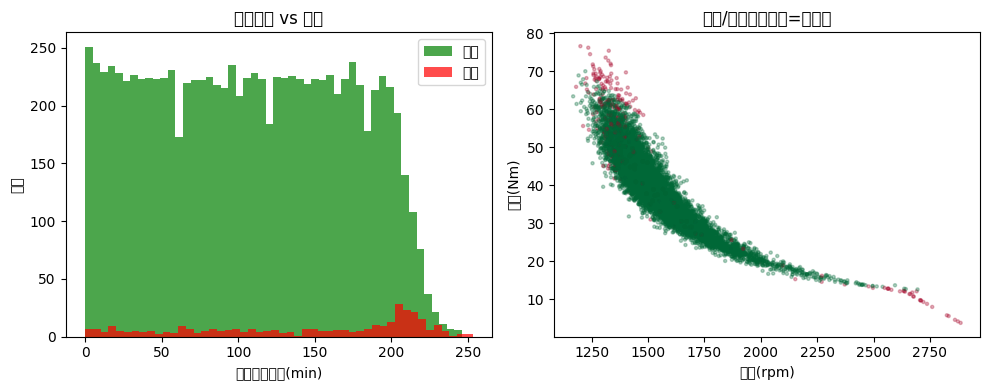

In [19]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']  # 加这行
plt.rcParams['axes.unicode_minus'] = False  # 加这行

# 看故障率
print(f"总故障次数: {df['Machine failure'].sum()}")
print(f"故障率: {df['Machine failure'].mean()*100:.2f}%")
print("\n各类故障分布：")
print(df[['TWF','HDF','PWF','OSF','RNF']].sum())

# 画图：刀具磨损 vs 故障
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df[df['Machine failure']==0]['Tool wear [min]'], bins=50, alpha=0.7, label='正常', color='green')
plt.hist(df[df['Machine failure']==1]['Tool wear [min]'], bins=50, alpha=0.7, label='故障', color='red')
plt.xlabel('刀具磨损时间(min)')
plt.ylabel('数量')
plt.title('刀具磨损 vs 故障')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(df['Rotational speed [rpm]'], df['Torque [Nm]'], 
            c=df['Machine failure'], cmap='RdYlGn_r', alpha=0.3, s=5)
plt.xlabel('转速(rpm)')
plt.ylabel('扭矩(Nm)')
plt.title('转速/扭矩分布（红=故障）')

plt.tight_layout()
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. 准备数据：选特征和目标
features = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
X = df[features]
y = df['Machine failure']

# 2. 切分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集: {len(X_train)}条，测试集: {len(X_test)}条")

# 3. 训练模型
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("模型训练完成！")

# 4. 评估模型
y_pred = model.predict(X_test)
print("\n=== 模型效果 ===")
print(classification_report(y_test, y_pred, target_names=['正常','故障']))

# 5. 看哪个特征最重要
import pandas as pd
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\n=== 特征重要性 ===")
print(importance)

训练集: 8000条，测试集: 2000条
模型训练完成！

=== 模型效果 ===
              precision    recall  f1-score   support

          正常       0.99      1.00      0.99      1939
          故障       0.82      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.90      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000


=== 特征重要性 ===
Torque [Nm]                0.320955
Rotational speed [rpm]     0.214712
Air temperature [K]        0.161565
Tool wear [min]            0.153936
Process temperature [K]    0.148831
dtype: float64


In [21]:
# 先安装库
import subprocess
subprocess.run(['pip', 'install', 'zhipuai', '-q'])
print("安装完成！")

安装完成！


In [22]:
from zhipuai import ZhipuAI

# 把引号里换成你的API Key
client = ZhipuAI(api_key="a340d621d3514dfb91bb9917428806ee.Zp1oJ2QDsjhEoDWo")

def analyze_equipment(air_temp, process_temp, rpm, torque, tool_wear):
    prompt = f"""
    你是一个工厂设备故障诊断专家。请分析以下设备运行参数：
    
    - 空气温度：{air_temp}K（正常范围：295-305K）
    - 加工温度：{process_temp}K（正常范围：305-315K）
    - 转速：{rpm}RPM（正常范围：1300-1600RPM）
    - 扭矩：{torque}Nm（正常范围：20-60Nm）
    - 刀具磨损：{tool_wear}min（超过200min需更换）
    
    请给出：
    1. 风险等级（低/中/高）
    2. 异常参数分析
    3. 建议措施
    用简洁专业的中文回答。
    """
    
    response = client.chat.completions.create(
        model="glm-4-flash",  # 免费模型
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# 测试一个正常设备
print("=== 测试1：正常设备 ===")
print(analyze_equipment(300, 310, 1500, 40, 50))

print("\n=== 测试2：异常设备 ===")
print(analyze_equipment(315, 325, 1200, 72, 220))

=== 测试1：正常设备 ===
1. 风险等级：高

2. 异常参数分析：
   - 空气温度：当前温度在正常范围内，无异常。
   - 加工温度：超过正常上限，可能存在过热风险，需进一步检查加工过程中的热管理系统。
   - 转速：处于正常范围内，无异常。
   - 扭矩：超过正常上限，可能导致设备过载，需检查传动系统和负载情况。
   - 刀具磨损：显著高于正常更换阈值，表明刀具磨损严重，需立即更换刀具。

3. 建议措施：
   - 立即停止设备运行，对加工温度过高和扭矩过大的原因进行排查。
   - 检查冷却系统是否正常，必要时进行清洗或维修。
   - 评估负载情况，调整加工参数或增加辅助冷却措施。
   - 立即更换磨损严重的刀具，确保加工质量。
   - 优化设备维护计划，增加对关键部件的检查和保养频率。

=== 测试2：异常设备 ===
1. 风险等级：高
2. 异常参数分析：
   - 空气温度：超出正常范围，可能存在过热风险，需检查冷却系统。
   - 加工温度：超出正常范围，可能导致材料变形或设备损坏，需检查加热系统。
   - 转速：低于正常范围，可能影响加工效率和质量，需检查驱动系统。
   - 扭矩：超出正常范围，可能导致设备过载或损坏，需检查传动系统。
   - 刀具磨损：超过更换标准，可能导致加工精度下降或设备损坏，需及时更换刀具。

3. 建议措施：
   - 检查冷却系统，确保空气温度在正常范围内。
   - 检查加热系统，确保加工温度在正常范围内。
   - 检查驱动系统和传动系统，确保转速和扭矩在正常范围内。
   - 更换磨损的刀具，确保加工精度和质量。
   - 定期检查设备，预防潜在故障。
